# 1. Time-frequency processing and tremor characteristics

What this notebook does:

1. computes the frequency characteristics of every patient's tremor
2. compares them across N / PD / ET
3. classifies patients from **mean and max frequency alone**, then adds one
   characteristic at a time so each contribution is visible

Run top to bottom. Needs `Data/`, `NewData/`, `pads_stretchhold/`, `pads_relaxed/`.

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
from frequency.characteristics import (patient_table, describe, classify,
                                     FEATURES, CLASS_NAMES)
from common.quaternion_data import load_quaternion_recordings
from common.load_2025 import load_2025_all
from common.loaders import load_pads_extracted

## Load the three cohorts

In [2]:
# Each in-house task and its PADS counterpart. PD vs ET is a rest-vs-posture
# question clinically, so both conditions are loaded: OUT/StretchHold is the
# postural task, REST/Relaxed the rest task.
cohorts = {
    '2015 OUT':         (load_quaternion_recordings('Data', action='OUT',
                                                    mode='angular_velocity'), slice(3, 6)),
    '2015 REST':        (load_quaternion_recordings('Data', action='REST',
                                                    mode='angular_velocity'), slice(3, 6)),
    'NewData OUT':      (load_2025_all(conditions=('OUT',)), slice(3, 6)),
    'PADS StretchHold': (load_pads_extracted('pads_stretchhold'), slice(0, 3)),
    'PADS Relaxed':     (load_pads_extracted('pads_relaxed'), slice(0, 3)),
}
tables = {n: patient_table(r, ch=c) for n, (r, c) in cohorts.items()}
for n, (X, y, _) in tables.items():
    print(f"{n:>18}  n={len(y):>4}  " +
          "  ".join(f"{c}={int((y==i).sum())}" for i, c in enumerate(CLASS_NAMES)))

          2015 OUT  n= 151  N=61  PD=75  ET=15
         2015 REST  n= 152  N=61  PD=75  ET=16
       NewData OUT  n=  56  N=27  PD=23  ET=6
  PADS StretchHold  n= 383  N=79  PD=276  ET=28
      PADS Relaxed  n= 383  N=79  PD=276  ET=28


## Tremor characteristics per class

`max_freq` dominant frequency &nbsp;|&nbsp; `mean_freq` spectral centroid &nbsp;|&nbsp;
`bandwidth` spread about the centroid &nbsp;|&nbsp; `inband_frac` 3-15 Hz share of
total power &nbsp;|&nbsp; `harm_ratio` power at 2f &nbsp;|&nbsp; `peak_sharp` peak
over mean in-band power.

In [3]:
for n, (X, y, _) in tables.items():
    describe(X, y, tag=n)


### 2015 OUT   n=151  N=61  PD=75  ET=15
characteristic                   N                  PD                  ET
      max_freq     7.87 +/-2.07        6.86 +/-1.93        7.12 +/-1.59   
     mean_freq     8.33 +/-0.68        7.22 +/-1.27        7.47 +/-0.90   
     bandwidth     2.87 +/-0.33        2.18 +/-0.58        2.19 +/-0.52   
   inband_frac     0.55 +/-0.13        0.74 +/-0.16        0.73 +/-0.14   
    harm_ratio     0.47 +/-0.40        0.26 +/-0.38        0.28 +/-0.38   
    peak_sharp     3.64 +/-1.88        7.51 +/-5.90        7.37 +/-5.03   

### 2015 REST   n=152  N=61  PD=75  ET=16
characteristic                   N                  PD                  ET
      max_freq     7.36 +/-2.03        5.67 +/-1.39        6.29 +/-1.20   
     mean_freq     8.20 +/-0.94        6.80 +/-1.14        7.49 +/-0.82   
     bandwidth     2.76 +/-0.34        2.40 +/-0.53        2.39 +/-0.48   
   inband_frac     0.66 +/-0.13        0.78 +/-0.15        0.76 +/-0.12   
    harm_ratio 

## Distributions — where each class sits in frequency

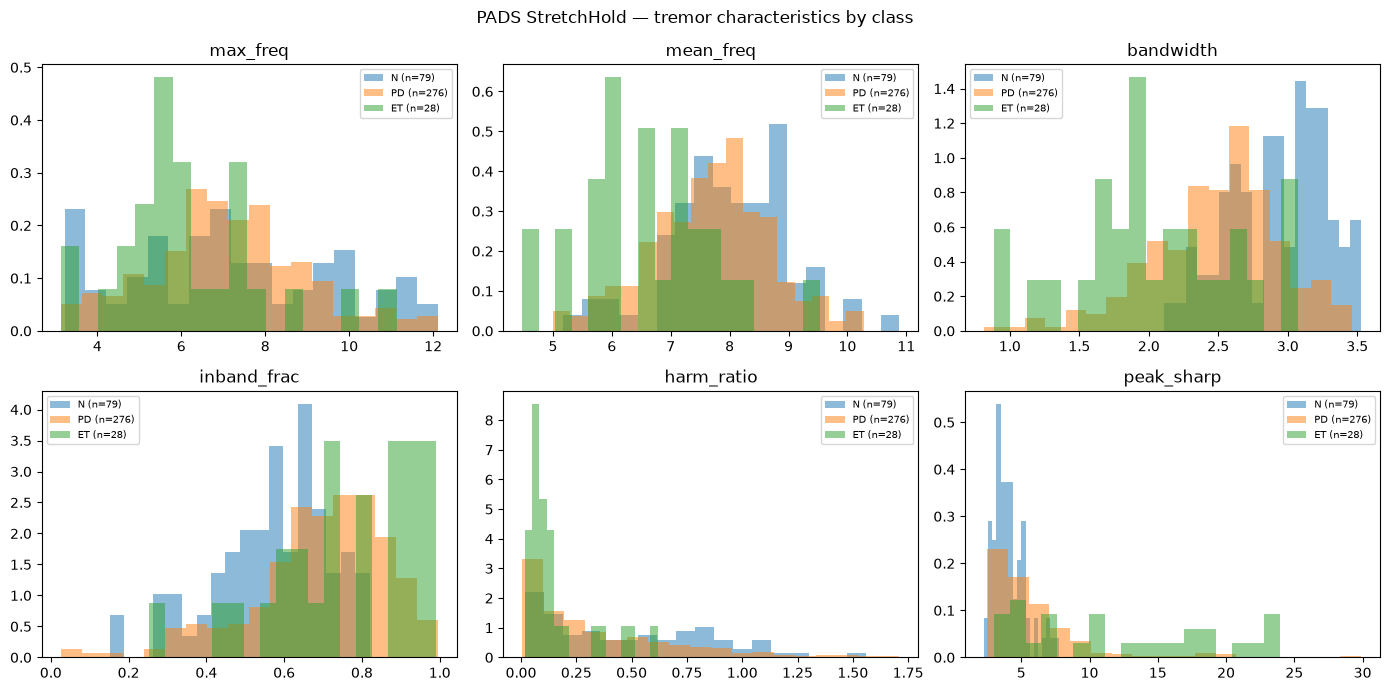

In [4]:
X, y, _ = tables['PADS StretchHold']          # largest cohort
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for j, name in enumerate(FEATURES):
    a = ax[j // 3][j % 3]
    for i, c in enumerate(CLASS_NAMES):
        v = X[y == i, j]
        v = v[np.isfinite(v)]
        if len(v):
            a.hist(v, bins=18, alpha=0.5, label=f'{c} (n={len(v)})', density=True)
    a.set_title(name); a.legend(fontsize=7)
fig.suptitle('PADS StretchHold — tremor characteristics by class')
fig.tight_layout(); plt.show()

## Classify from frequency alone

Features are added cumulatively, starting from `max_freq`, so the marginal value
of each one is visible.

In [5]:
for n, (X, y, _) in tables.items():
    classify(X, y, tag=n, axis='N_vs_Tremor')
    # PD vs ET: average over 10 re-shuffled CV partitions (one partition swings
    # 0.32-0.52 at 15 ET on the CV seed alone), print the shuffled-label null
    # built from the same averaged statistic, and skip a cohort with fewer than
    # 10 ET (NewData has 6).
    classify(X, y, tag=n, axis='PD_vs_ET', n_perm=200, min_pos=10, n_repeats=10)


  2015 OUT  N_vs_Tremor   n=151  Tremor=90
                               features used     AUC    prec     rec
                                    max_freq   0.623   0.707   0.644
                        max_freq + mean_freq   0.783   0.819   0.656
            max_freq + mean_freq + bandwidth   0.869   0.873   0.767
max_freq + mean_freq + bandwidth + inband_frac   0.887   0.900   0.800
max_freq + mean_freq + bandwidth + inband_frac + harm_ratio   0.883   0.910   0.789
max_freq + mean_freq + bandwidth + inband_frac + harm_ratio + peak_sharp   0.890   0.910   0.789

  2015 OUT  PD_vs_ET   n=90  ET=15
                               features used     AUC    prec     rec  AUC range over CV seeds


                                    max_freq   0.412   0.104   0.267   [0.318, 0.517]
                        max_freq + mean_freq   0.393   0.110   0.340   [0.295, 0.487]


            max_freq + mean_freq + bandwidth   0.363   0.084   0.220   [0.282, 0.407]
max_freq + mean_freq + bandwidth + inband_frac   0.321   0.068   0.187   [0.261, 0.408]


max_freq + mean_freq + bandwidth + inband_frac + harm_ratio   0.308   0.066   0.173   [0.221, 0.389]
max_freq + mean_freq + bandwidth + inband_frac + harm_ratio + peak_sharp   0.288   0.061   0.160   [0.217, 0.348]


           shuffled-label null, all features   95 % range [0.334, 0.662]   p=0.985   -> NOT distinguishable from chance

  2015 REST  N_vs_Tremor   n=152  Tremor=91
                               features used     AUC    prec     rec
                                    max_freq   0.728   0.753   0.670
                        max_freq + mean_freq   0.794   0.786   0.725
            max_freq + mean_freq + bandwidth   0.793   0.787   0.692
max_freq + mean_freq + bandwidth + inband_frac   0.822   0.800   0.703
max_freq + mean_freq + bandwidth + inband_frac + harm_ratio   0.821   0.793   0.714
max_freq + mean_freq + bandwidth + inband_frac + harm_ratio + peak_sharp   0.830   0.783   0.714

  2015 REST  PD_vs_ET   n=91  ET=16
                               features used     AUC    prec     rec  AUC range over CV seeds


...

                        max_freq + mean_freq   0.751   0.179   0.657   [0.744, 0.755]


            max_freq + mean_freq + bandwidth   0.746   0.176   0.639   [0.740, 0.753]
max_freq + mean_freq + bandwidth + inband_frac   0.789   0.225   0.700   [0.775, 0.798]


max_freq + mean_freq + bandwidth + inband_frac + harm_ratio   0.776   0.214   0.661   [0.762, 0.794]


max_freq + mean_freq + bandwidth + inband_frac + harm_ratio + peak_sharp   0.765   0.193   0.639   [0.744, 0.786]


           shuffled-label null, all features   95 % range [0.380, 0.605]   p=0.000   -> above chance


## Is the signal processing right? Checked, not assumed

Before reading the PD-vs-ET numbers as a property of the patients, the chain
that produces them is checked against things that do not share its code:

* **angular velocity** from `process_quaternion_data` against an independent
  SciPy `Rotation` computation of the same central difference;
* **quaternion convention**: switching `xyzw` to `wxyz` (the files put the
  largest component in column 0 about as often as in column 3);
* **no CV at all**: each feature's raw AUC for ET vs PD, so a classifier or a
  CV artefact cannot be what produces the number.

In [6]:
import glob, pandas as pd
from scipy.spatial.transform import Rotation
from scipy.signal import welch
from sklearn.metrics import roc_auc_score
from signal_processing.quaternion import process_quaternion_data

err, conv = [], []
for p in sorted(glob.glob('Data/raw_quaternion/OUT/*/*.txt'))[::10]:
    Q = pd.read_csv(p, header=None).to_numpy(float)
    x = process_quaternion_data(Q.astype(np.float32))
    xw = process_quaternion_data(Q.astype(np.float32), convention='wxyz')
    f, P = welch(x, fs=100, nperseg=512, axis=-1)
    _, Pw = welch(xw, fs=100, nperseg=512, axis=-1)
    conv.append(np.abs(P.sum() - Pw.sum()) / P.sum())
    for s in range(3):
        r = Rotation.from_quat(Q[:, 4 * s:4 * s + 4])          # scalar-last
        w = (r[2:] * r[:-2].inv()).as_rotvec() * 50.0           # 2-sample step, fs=100
        err.append(np.linalg.norm(x[3 * s:3 * s + 3].T - w) / np.linalg.norm(w))
print(f"angular velocity vs independent SciPy: relative error median {np.median(err):.5f}, max {np.max(err):.5f}")
print(f"xyzw vs wxyz convention: total power differs by at most {np.max(conv):.4f}")

print("\nraw (no-CV) AUC of each feature for ET vs PD; 0.5 = no difference, <0.5 = ET lower")
print(f"{'':>18}" + "".join(f"{f:>12}" for f in FEATURES))
for n, (X, y, _) in tables.items():
    m = y != 0
    if (y == 2).sum() < 10:
        continue
    ya = (y[m] == 2).astype(int)
    print(f"{n:>18}" + "".join(f"{roc_auc_score(ya, X[m][:, j]):>12.2f}" for j in range(len(FEATURES))))

angular velocity vs independent SciPy: relative error median 0.00009, max 0.00109
xyzw vs wxyz convention: total power differs by at most 0.0042

raw (no-CV) AUC of each feature for ET vs PD; 0.5 = no difference, <0.5 = ET lower
                      max_freq   mean_freq   bandwidth inband_frac  harm_ratio  peak_sharp
          2015 OUT        0.54        0.52        0.49        0.49        0.51        0.51
         2015 REST        0.64        0.67        0.47        0.43        0.51        0.51
  PADS StretchHold        0.33        0.23        0.27        0.63        0.34        0.78
      PADS Relaxed        0.30        0.23        0.31        0.62        0.42        0.72


## Why PD vs ET fails in-house on OUT — the patients, not the method

**The processing is not the cause.** Angular velocity agrees with an independent
SciPy computation to 0.01 %, the quaternion convention changes band power by
<0.2 %, and there are no duplicate or mislabelled files in OUT (see
`python -m experiments.verify_data`; its one failure is four `N 2` REST/WING
files that hold accelerometer data, |q| ~ 9.8, not OUT).

**On 2015 OUT every feature has a raw AUC of 0.46-0.54 before any model is
fitted.** ET and PD have the same median on all six. The 0.31 the old version of
this notebook printed came from one CV partition: the same one-feature model
reads 0.32-0.52 depending only on the CV seed, and seed 0 was the lowest.
Averaged over partitions it is still below 0.5, which is what cross-validation
does when there is no signal and the smaller class sits inside the larger one's
spread (ET's feature ranges are narrower than PD's), and it stays inside the
chance range on two of three sensors.

The cell below compares the tremor itself. **PADS ET patients have the
textbook ET tremor: stronger, sharper and slower than PD. In-house ET patients
at OUT do not**: their tremor matches in-house PD on amplitude, sharpness and
frequency.

In [7]:
from scipy.signal import butter, sosfiltfilt
from scipy.stats import mannwhitneyu
sos = butter(4, [3 / 50, 15 / 50], btype='band', output='sos')
ps, mf = FEATURES.index('peak_sharp'), FEATURES.index('max_freq')
print(f"{'cohort':<18}{'tremor RMS log10, ET vs PD':>32}{'peak_sharp':>26}{'max_freq (Hz)':>24}")
for n, (recs, ch) in cohorts.items():
    X, y, pats = tables[n]
    rms = {}
    for r in recs:
        x = np.asarray(r.x[ch] if r.x.shape[0] > 3 else r.x, float)
        rms.setdefault(r.subject, []).append(np.sqrt(np.mean(sosfiltfilt(sos, x, axis=-1) ** 2)))
    R = np.array([np.log10(np.mean(rms[p])) for p in pats])
    e, d = y == 2, y == 1
    cell = lambda a, b, f: (f"{f.format(np.median(a))} vs {f.format(np.median(b))}"
                            f" (p={mannwhitneyu(a, b).pvalue:.2f})")
    print(f"{n:<18}{cell(R[e], R[d], '{:+.2f}'):>32}"
          f"{cell(X[e, ps], X[d, ps], '{:.1f}'):>26}{cell(X[e, mf], X[d, mf], '{:.1f}'):>24}")

cohort                  tremor RMS log10, ET vs PD                peak_sharp           max_freq (Hz)
2015 OUT                   -1.69 vs -1.66 (p=0.46)       4.9 vs 4.9 (p=0.87)     6.6 vs 6.6 (p=0.64)


2015 REST                  -2.09 vs -1.94 (p=0.10)       6.0 vs 5.8 (p=0.94)     6.1 vs 5.6 (p=0.09)
NewData OUT                -1.78 vs -1.83 (p=0.51)       4.1 vs 6.4 (p=0.38)     7.3 vs 7.7 (p=0.63)


PADS StretchHold           -1.38 vs -1.72 (p=0.00)      10.4 vs 4.8 (p=0.00)     5.8 vs 6.9 (p=0.00)


PADS Relaxed               -1.71 vs -1.93 (p=0.00)       9.6 vs 5.3 (p=0.00)     4.8 vs 6.1 (p=0.00)


## At rest the in-house cohort does separate PD from ET — in the opposite direction to PADS

In 2015 REST the dominant frequency *is* different: PD rest tremor is slower
than ET's, the textbook ordering. PADS shows the reverse at both tasks: its ET
patients are slower than its PD. A single model trained on the merged cohorts is
being taught two contradictory frequency rules, which is consistent with a
PADS-trained model scoring chance in-house (0.47).

The 2015 REST result rests on 16 ET. It is above its chance range on all three
sensors (p = 0.015 / 0.025 / 0.035 with CV averaged over 10 partitions), but it
**does not replicate** (`reports/rest_replication.md`): pooled with NewData it
falls inside its null (0.573, p = 0.162), and a rule frozen on 2015 is
*reversed* on PADS Relaxed (0.280, p < 0.001). The robust finding is that the
PD-vs-ET frequency relationship is cohort-dependent.

In [8]:
print(f"{'':>18}{'PD max_freq':>13}{'ET max_freq':>13}{'raw AUC (ET higher)':>22}")
for n, (X, y, _) in tables.items():
    if (y == 2).sum() < 10:
        continue
    m = y != 0
    print(f"{n:>18}{np.median(X[y == 1, 0]):>13.2f}{np.median(X[y == 2, 0]):>13.2f}"
          f"{roc_auc_score((y[m] == 2).astype(int), X[m][:, 0]):>22.2f}")

recs_rest = cohorts['2015 REST'][0]
for s, name in enumerate(('hand', 'lower arm', 'upper arm')):
    Xs, ys, _ = patient_table(recs_rest, ch=slice(3 * s, 3 * s + 3))
    classify(Xs, ys, tag=f'2015 REST {name}', axis='PD_vs_ET', n_perm=200,
             min_pos=10, n_repeats=10)

                    PD max_freq  ET max_freq   raw AUC (ET higher)
          2015 OUT         6.64         6.64                  0.54
         2015 REST         5.57         6.05                  0.64
  PADS StretchHold         6.93         5.81                  0.33
      PADS Relaxed         6.05         4.83                  0.30

  2015 REST hand  PD_vs_ET   n=91  ET=16
                               features used     AUC    prec     rec  AUC range over CV seeds


                                    max_freq   0.688   0.305   0.644   [0.659, 0.699]
                        max_freq + mean_freq   0.707   0.270   0.625   [0.690, 0.723]


            max_freq + mean_freq + bandwidth   0.727   0.272   0.569   [0.708, 0.745]


max_freq + mean_freq + bandwidth + inband_frac   0.715   0.267   0.588   [0.698, 0.746]


max_freq + mean_freq + bandwidth + inband_frac + harm_ratio   0.700   0.262   0.575   [0.670, 0.718]
max_freq + mean_freq + bandwidth + inband_frac + harm_ratio + peak_sharp   0.683   0.252   0.556   [0.639, 0.711]


...

           shuffled-label null, all features   95 % range [0.301, 0.649]   p=0.025   -> above chance

  2015 REST upper arm  PD_vs_ET   n=91  ET=16
                               features used     AUC    prec     rec  AUC range over CV seeds


                                    max_freq   0.632   0.275   0.662   [0.602, 0.652]
                        max_freq + mean_freq   0.667   0.252   0.544   [0.641, 0.692]


            max_freq + mean_freq + bandwidth   0.679   0.244   0.525   [0.666, 0.696]
max_freq + mean_freq + bandwidth + inband_frac   0.685   0.280   0.637   [0.644, 0.705]


max_freq + mean_freq + bandwidth + inband_frac + harm_ratio   0.663   0.260   0.562   [0.649, 0.673]
max_freq + mean_freq + bandwidth + inband_frac + harm_ratio + peak_sharp   0.670   0.266   0.562   [0.638, 0.688]


           shuffled-label null, all features   95 % range [0.287, 0.675]   p=0.035   -> above chance


## What this shows (measured, see `reports/inhouse_pd_vs_et.md`)

* **The signal processing is correct.** Angular velocity matches an independent
  SciPy computation to 0.01 %; the quaternion convention does not matter
  (<0.2 %). The one data defect found is four `N 2` REST/WING files that contain
  accelerometer data (|q| ~ 9.8); they are controls, not OUT, and are reported
  by `verify_data` check 13 rather than dropped.
* **N-vs-Tremor reaches precision ~0.91 from six interpretable frequency
  numbers** on 2015 OUT and PADS StretchHold.
* **`peak_sharp` is the strongest single characteristic on PADS**: ET tremor is
  far more sharply peaked than PD there.
* **In-house OUT carries no PD-vs-ET information.** Every feature's raw AUC is
  0.46-0.54 before any model. The old 0.31 was one unlucky CV partition; the
  cross-validated value stays at or below 0.5 because there is nothing to learn.
* **2015 REST shows it weakly** (PD slower, p ~ 0.04 on the pipeline's sensor)
  but it **does not replicate** on the pooled in-house set, and **PADS runs the
  opposite way** (ET slower) at both tasks: a 2015 rule scores 0.28 on PADS.
  The PD-vs-ET frequency relationship is cohort-dependent
  (`reports/rest_replication.md`). Giving the deep model in-house REST did not
  help either (`reports/inhouse_rest.md`).
* An earlier version of this cell said instantaneous-frequency stability
  "works" on 2015 (AUC 0.652). At 15 ET that is inside the chance range and
  predates the trajectory end-point fix, so it is not evidence of a signal.